# DrugEx ROCS Quick Start: Shape-Based RL

RL training for CCR2 ligand design using RDKit ROCS shape similarity scoring.

**Prerequisites:** Run fine-tuning first (`python prepare_models.py`)

**What This Does:**
- Trains RL model to generate CCR2 ligands optimized for shape similarity (ROCS) and synthetic accessibility
- Uses predefined settings from `config.py`
- Saves trained model for molecule generation

## ROCS Threshold Validation

Before RL training, we validate the ROCS threshold used to reward shape-similar molecules. 

**Why:** The threshold determines which molecules are considered "desired" during RL. Too high → miss actives. Too low → reward decoys.

**Method:** ROC analysis compares 75 CCR2 actives vs 500 decoys using the same conformer settings as RL training. We find the optimal threshold that maximizes separation (Youden's Index).

Results validate whether `config.py`'s `ROCS_THRESHOLD = 1.2` is appropriate or should be adjusted.

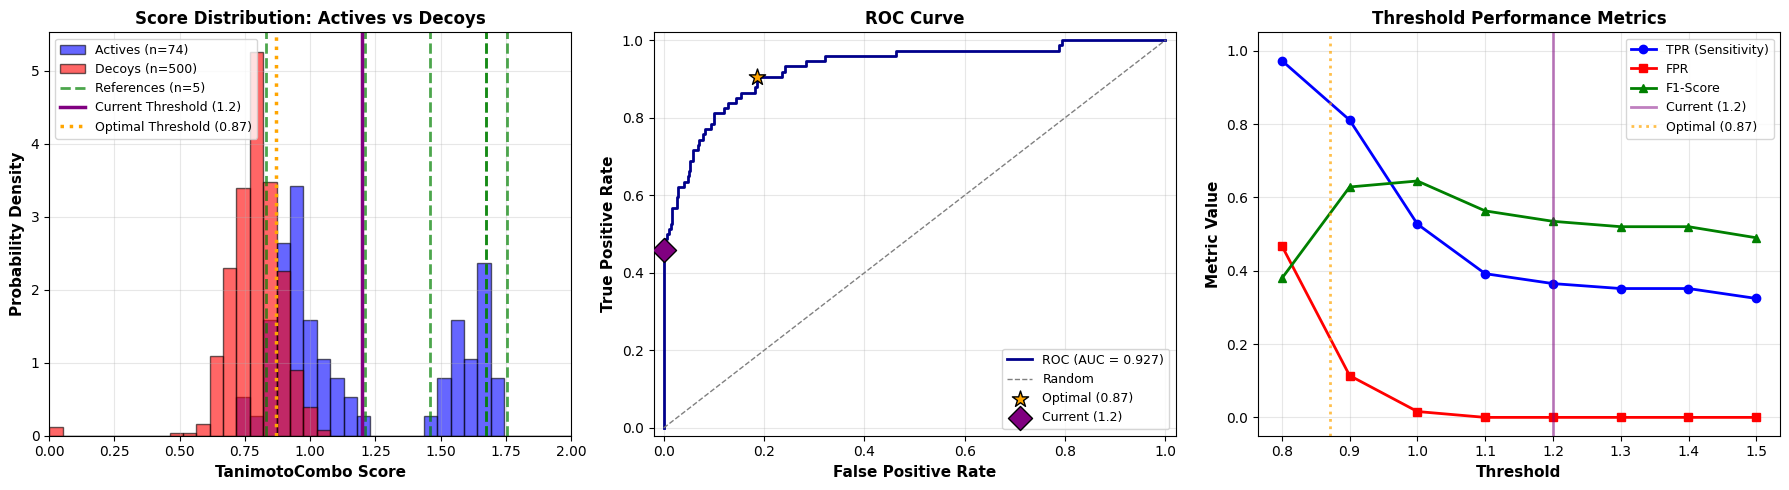

Current config threshold: 1.2
Optimal threshold (Youden's Index): 0.871


In [1]:
# Run threshold validation (uses config.py defaults automatically)
from threshold_analysis import run_threshold_analysis
from config import ROCS_THRESHOLD

results = run_threshold_analysis(
    actives_csv='rocs_rl_ccr/rdkit_cdpkit/actives_decoys/actives_ccr2_N75.csv',
    decoys_csv='rocs_rl_ccr/rdkit_cdpkit/actives_decoys/decoys_ccr2_N500.csv',
    verbose=False,  # Minimal output
    show_plots=True
)

# Display threshold recommendation
optimal_threshold = results['optimal_threshold']
print(f"Current config threshold: {ROCS_THRESHOLD}")
print(f"Optimal threshold (Youden's Index): {optimal_threshold:.3f}")


In [ ]:
# Imports
import time
import pandas as pd
import matplotlib.pyplot as plt
from drugex.training.explorers import SequenceExplorer
from drugex.training.monitors import FileMonitor
from config import setup_rl_rdkit, RL_EPOCHS, RL_EPSILON, RL_N_SAMPLES

In [ ]:
# Setup (loads models, creates environment with predefined settings)
agent, mutate, env, output_dir = setup_rl_rdkit()

In [ ]:
# Create RL explorer
explorer = SequenceExplorer(
    agent=agent,
    env=env,
    mutate=mutate,
    epsilon=RL_EPSILON,
    n_samples=RL_N_SAMPLES,
)

print(f"RL Config: {RL_EPOCHS} epochs, epsilon={RL_EPSILON}, samples={RL_N_SAMPLES}")

In [ ]:
# Train RL model
output_base = output_dir / 'CCR2_rdkit_reinforced'
monitor = FileMonitor(str(output_base), save_smiles=True, reset_directory=True)

start = time.time()
explorer.fit(monitor=monitor, epochs=RL_EPOCHS)
monitor.close()

print(f"\nCompleted in {(time.time()-start)/60:.1f} minutes")
print(f"Model saved: {output_base}.pkg")

In [ ]:
df = pd.read_csv(f'{output_base}_fit.tsv', sep='\t')
df


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv(f'{output_base}_fit.tsv', sep='\t')

df.plot(x='Epoch', y=['desired_ratio', 'avg_amean'], subplots=True, layout=(1,2),
        figsize=(12,4), marker='o', ylim=(0,1.1), grid=True, legend=False, title=['Desired Molecules Ratio','Average Score'])

plt.tight_layout()
plt.show()

print("\nFinal 5 epochs:\n", df[['Epoch','desired_ratio','avg_amean']].tail())


## Next Steps

### Generate Molecules
```bash
python generate_molecules.py
```

### Try Other Backends
- CDPKit: `python run_cdpkit_rocs.py`
- OpenEye: `python run_openeye_rocs.py`

### Customize
Edit `config.py` to change:
- RL parameters (epochs, epsilon, samples)
- Conformer settings (max_conformers, max_isomers)
- Reference ligands (CCR2_SDF path)

In [ ]:
# Analyze SA score evolution across epochs
smiles_df = pd.read_csv(f'{output_base}_smiles.tsv', sep='\t')

# Filter for valid molecules only (exclude invalid with SA=0)
valid_smiles = smiles_df[smiles_df['Valid'] == 1.0]

# Calculate mean SA score per epoch
sa_per_epoch = valid_smiles.groupby('Epoch')['SA'].mean().reset_index()

# Create plot
plt.figure(figsize=(10, 5))
plt.plot(sa_per_epoch['Epoch'], sa_per_epoch['SA'], marker='o', linewidth=2, markersize=5)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Mean SA Score', fontsize=12)
plt.title('Mean Synthetic Accessibility Score per Epoch', fontsize=14, fontweight='bold')
plt.ylim(0, 1.05)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Print summary statistics
print("\nSynthetic Accessibility Score Summary:")
print(f"Initial (Epoch 1): {sa_per_epoch.iloc[0]['SA']:.3f}")
print(f"Final (Epoch 50): {sa_per_epoch.iloc[-1]['SA']:.3f}")
print(f"Minimum: {sa_per_epoch['SA'].min():.3f}")
print(f"Maximum: {sa_per_epoch['SA'].max():.3f}")
print(f"Overall Mean: {sa_per_epoch['SA'].mean():.3f}")
